# Next Character Prediction Using MLP

Build a generative model that predicts the next character in a sequence using a MLP.

Based on the paper titled '[A Neural Probabilistic Language Model](https://www.jmlr.org/papers/volume3/bengio03a/bengio03a.pdf)' by Bengio, et al.

In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

In [2]:
# read the dataset (names.txt)
words = open('names.txt', 'r').read().splitlines()

In [3]:
chars = sorted(list(set('.abcdefghijklmnopqrstuvwxyz')))
chartoi = {s:i for i, s in enumerate(chars)}
itochar = {i:s for s,i in chartoi.items()}

In [4]:
# build the dataset

BLOCK_SIZE = 3 # Defines the context length ie. how many characters to use to predict the next one
X, Y = [], []

for w in words:
    #print(w)
    context = [0] * BLOCK_SIZE
    for ch in w + '.':
        idx = chartoi[ch]
        X.append(context)
        Y.append(idx)
        #print(f"{"".join(itochar[c] for c in context)} --> {ch}")
        context = context[1:] + [idx] # pop and push

X = torch.tensor(X)
Y = torch.tensor(Y)

In [5]:
# split the data into training, validation, and test set

N = X.shape[0] 
n_train = int(0.8 * N)
n_val = int(0.1 * N)
# n_test is whatever is left over

indices = torch.randperm(N)

train_indices = indices[:n_train]
val_indices = indices[n_train : n_train + n_val]
test_indices = indices[n_train + n_val:]

X_train, Y_train = X[train_indices], Y[train_indices]
X_val, Y_val = X[val_indices], Y[val_indices]
X_test, Y_test = X[test_indices], Y[test_indices]

print(f"Train: {X_train.shape}, {Y_train.shape}")
print(f"Val:   {X_val.shape}, {Y_val.shape}")
print(f"Test:  {X_test.shape}, {Y_test.shape}")

Train: torch.Size([182516, 3]), torch.Size([182516])
Val:   torch.Size([22814, 3]), torch.Size([22814])
Test:  torch.Size([22816, 3]), torch.Size([22816])


In [8]:
class MLP:

    def __init__(self, block_size=3, embedding_dimensions=2, hidden_layer_size=300, output_layer_size=len(chars)):
        self.EMBEDDING_DIMENSIONS = embedding_dimensions # the dimensionality of the embedding space
        self.HIDDEN_LAYER_SIZE = hidden_layer_size # number of neurons in hidden layer
        self.OUTPUT_LAYER_SIZE = output_layer_size # number of neurons in output layer
        self.BLOCK_SIZE = block_size # context window length

        # initialize weights
        g = torch.Generator().manual_seed(2147483647) # for reproducibility
        self.C = torch.randn((len(chars), self.EMBEDDING_DIMENSIONS), requires_grad=True, generator=g)
        self.W1 = torch.randn((self.BLOCK_SIZE * self.EMBEDDING_DIMENSIONS, self.HIDDEN_LAYER_SIZE), requires_grad=True, generator=g)
        self.b1 = torch.randn(self.HIDDEN_LAYER_SIZE, requires_grad=True, generator=g)
        self.W2 = torch.randn((self.HIDDEN_LAYER_SIZE, self.OUTPUT_LAYER_SIZE), requires_grad=True, generator=g)
        self.b2 = torch.randn(self.OUTPUT_LAYER_SIZE, requires_grad=True, generator=g)
        self.parameters = [self.C, self.W1, self.b1, self.W2, self.b2]

    # forward pass through the MLP and return logits
    def _compute_logits(self, X):
        emb = self.C[X]
        X1 = F.tanh((emb.flatten(start_dim=1) @ self.W1) + self.b1)
        logits = (X1 @ self.W2) + self.b2
        return logits

    # forward pass throught MLP and return next char probs
    def forward(self, X):
        probs = F.softmax(self._compute_logits(X), dim=1)
        return probs

    # do a forward pass and compute cross-entropy loss (wrt. actual labels)
    def forward_and_compute_loss(self, X, Y):
        loss = F.cross_entropy(self._compute_logits(X), Y)
        return loss

    # zero grads all the weights in the MLP
    def zero_grad(self):
        for p in self.parameters:
            p.grad = None

    # update weights based on their calculated gradients
    def update_weights(self, learning_rate):
        for p in self.parameters:
            p.data += -learning_rate * p.grad

In [9]:
mlp = MLP()

---Training complete---
Final loss: 2.251555919647217


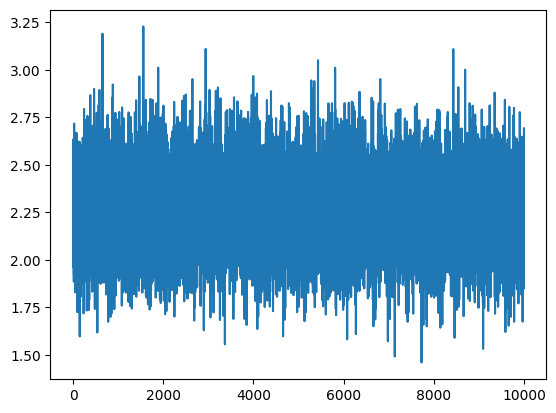

In [31]:
# train the MLP

EPOCHS = 10000
LEARNING_RATE = 0.01
MINI_BATCH_SIZE = 32

lossi = []
stepi = []

for e in range(EPOCHS):
    # construct mini-batch
    ix = torch.randint(0, X_train.shape[0], (MINI_BATCH_SIZE,))
    
    loss = mlp.forward_and_compute_loss(X_train[ix], Y_train[ix])

    stepi.append(e)
    lossi.append(loss.item())
    
    mlp.zero_grad()
    loss.backward()

    mlp.update_weights(LEARNING_RATE)

    #if e % 10 == 0:
        #print(f"Training loss at epoch {e}: {loss.item()}")

print(f"---Training complete---")
print(f"Final loss: {mlp.forward_and_compute_loss(X_train, Y_train).item()}")

plt.plot(stepi, lossi)

In [33]:
# evaluating model on the validation set

print(f"Loss on validation set: {mlp.forward_and_compute_loss(X_val, Y_val).item()}")

Loss on validation set: 2.2798731327056885


In [40]:
# generate new names using the MLP model

for i in range(1, 6):
    generated_name = "..."
    while True:
        x = torch.tensor([[chartoi[ch] for ch in generated_name[-3:]]])
        output_probs = mlp.forward(x)
        next_char_i = torch.multinomial(output_probs, num_samples=1, replacement=True).item()
        next_char = itochar[next_char_i]
        if next_char == ".":
            break
        generated_name += next_char
    print(f"Generated name {i}: {generated_name[3:]}")

Generated name 1: sae
Generated name 2: adrieri
Generated name 3: jamiaraunereidelyn
Generated name 4: neshah
Generated name 5: tty


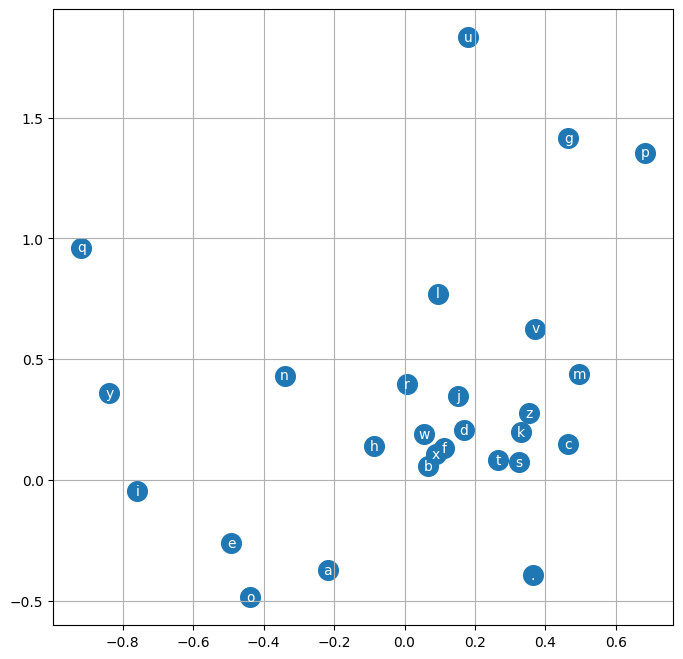

In [42]:
# visualize the embeddings

plt.figure(figsize=(8,8))
plt.scatter(mlp.C[:,0].data, mlp.C[:,1].data, s=200)
for i in range(mlp.C.shape[0]):
    plt.text(mlp.C[i,0].item(), mlp.C[i,1].item(), itochar[i], ha="center", va="center", color='white')
plt.grid('minor')